In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

<h1>Feature Selection</h1>

In [ ]:
# loading the dataset
df = pd.read_csv('hamon_googlefit_medical_realistic.csv')

# defining the feature categories
identifier_cols = ['user_id', 'day_index']
target_col = 'cardiometabolic_risk_state'

# mapping lifestyle and biomarker features
lifestyle_features = [
    'steps', 'calories_burned', 'calories_consumed', 'move_minutes',
    'distance_km', 'sleep_hours', 'sleep_efficiency', 'water_intake_l'
]
biomarker_features = [
    'avg_heart_rate', 'resting_hr', 'bp_systolic', 'bp_diastolic',
    'fasting_glucose', 'spo2', 'hrv', 'bmi'
]

# keeping only the features we need, in df
df = df[identifier_cols + lifestyle_features + biomarker_features + [target_col]].copy()

display(df.head())
df.shape

,user_id,day_index,steps,calories_burned,calories_consumed,move_minutes,distance_km,sleep_hours,sleep_efficiency,water_intake_l,avg_heart_rate,resting_hr,bp_systolic,bp_diastolic,fasting_glucose,spo2,hrv,bmi,cardiometabolic_risk_state
0,1,1,10362,2038,2246,71,7.77,7.58540,0.93389,2.6,76,55,127.0,83.0,NaN,95,56,30.753735,2
1,1,2,11127,2337,2497,74,8.35,NaN,NaN,2.3,76,54,NaN,NaN,NaN,96,58,30.753735,2
2,1,3,11771,2098,2648,61,8.83,7.01264,0.91370,1.8,72,54,NaN,NaN,111.0,95,59,30.753735,2
3,1,4,12574,2135,2923,83,9.43,NaN,NaN,2.1,78,54,NaN,NaN,109.0,95,58,30.753735,2
4,1,5,10253,2058,2372,73,7.69,NaN,NaN,2.8,74,53,127.0,82.0,NaN,97,60,30.753735,2


(90000, 19)

<h1>Data Preprocessing</h1>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. INITIAL SORTING & MISSING DATA HANDLING
df = df.sort_values(by=['user_id', 'day_index'])

user_counts = df['user_id'].value_counts()
valid_users = user_counts[user_counts >= 2].index
df = df[df['user_id'].isin(valid_users)].copy()

def impute_patient_data(x):
    return x.interpolate(method='linear', limit_direction='both').ffill().bfill()

df_imputed = df.copy()
cols_to_impute = lifestyle_features + biomarker_features
df_imputed[cols_to_impute] = df_imputed.groupby('user_id')[cols_to_impute].transform(impute_patient_data)

global_means = df_imputed[cols_to_impute].mean()
df_imputed[cols_to_impute] = df_imputed[cols_to_impute].fillna(global_means)


# 2. FEATURE ENGINEERING (Creating features)
df_imputed['caloric_balance'] = df_imputed['calories_consumed'] - df_imputed['calories_burned']
df_imputed['sleep_quality_index'] = df_imputed['sleep_hours'] * df_imputed['sleep_efficiency']
df_imputed['cardio_stress_index'] = df_imputed['resting_hr'] / df_imputed['hrv']
df_imputed['blood_pressure_pulse'] = df_imputed['bp_systolic'] - df_imputed['bp_diastolic']

engineered_features = ['caloric_balance', 'sleep_quality_index', 'cardio_stress_index', 'blood_pressure_pulse']

# PRIORITY ORDERING
# We put the engineered features first
# so that the correlation algorithm drops columns from right to left
# By putting ours on the left, they are protected!
all_current_features = engineered_features + lifestyle_features + biomarker_features

print(f"Total features after engineering: {len(all_current_features)}")

# 3. ALGORITHMIC FEATURE SELECTION (Correlation)
corr_matrix = df_imputed[all_current_features].corr().abs()

threshold = 0.85
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
print(f"Redundant features identified to drop: {features_to_drop}")

final_features_to_use = [f for f in all_current_features if f not in features_to_drop]
print(f"Final optimized feature count: {len(final_features_to_use)}")

# 4. SCALING AND PADDING
scaler = StandardScaler()
df_imputed[final_features_to_use] = scaler.fit_transform(df_imputed[final_features_to_use])

max_timesteps = df_imputed['day_index'].nunique()
num_features = len(final_features_to_use)
unique_users = df_imputed['user_id'].unique()
num_users = len(unique_users)

X_padded = np.full((num_users, max_timesteps, num_features), np.nan)
Y_target = np.zeros(num_users)

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}

for user_id, group in df_imputed.groupby('user_id'):
    idx = user_to_idx[user_id]
    user_features = group[final_features_to_use].values
    time_steps_available = user_features.shape[0]

    X_padded[idx, :time_steps_available, :] = user_features
    Y_target[idx] = group[target_col].iloc[0]

print(f"Preprocessing Complete")
print(f"Final 3D Time Series Shape (X): {X_padded.shape} -> [Patients, Timesteps, Optimized Features]")
print(f"Final Target Array Shape (Y): {Y_target.shape}")

Total features after engineering: 20
Redundant features identified to drop: ['move_minutes', 'distance_km', 'sleep_hours', 'sleep_efficiency', 'bp_diastolic']
Final optimized feature count: 15
Preprocessing Complete
Final 3D Time Series Shape (X): (3000, 30, 15) -> [Patients, Timesteps, Optimized Features]
Final Target Array Shape (Y): (3000,)


In [ ]:
# 5. GENERATING FINAL CATEGORY LISTS
# Defining which of our new engineered features belong to which category
engineered_lifestyle = ['caloric_balance', 'sleep_quality_index']
engineered_biomarkers = ['cardio_stress_index', 'blood_pressure_pulse']

# automatically sort the 15 surviving features into their new lists
final_lifestyle_features = [f for f in final_features_to_use if f in lifestyle_features or f in engineered_lifestyle]
final_biomarker_features = [f for f in final_features_to_use if f in biomarker_features or f in engineered_biomarkers]

print(f"Final Feature Breakdown")
print(f"Total Lifestyle Features ({len(final_lifestyle_features)}): {final_lifestyle_features}")
print(f"Total Biomarker Features ({len(final_biomarker_features)}): {final_biomarker_features}")

Final Feature Breakdown
Total Lifestyle Features (6): ['caloric_balance', 'sleep_quality_index', 'steps', 'calories_burned', 'calories_consumed', 'water_intake_l']
Total Biomarker Features (9): ['cardio_stress_index', 'blood_pressure_pulse', 'avg_heart_rate', 'resting_hr', 'bp_systolic', 'fasting_glucose', 'spo2', 'hrv', 'bmi']


Visualizing the preprocessed data

In [ ]:
print(f"Total Patients (Samples): {X_padded.shape[0]}")
print(f"Max Timesteps (Days):     {X_padded.shape[1]}")
print(f"Features per Timestep:    {X_padded.shape[2]}")

# inspecting the first user in the array (Index 0)
user_idx = 0
actual_user_id = unique_users[user_idx]

print(f"Target Classification Label (Y): {Y_target[user_idx]}")

# Using our final feature list
user_0_df = pd.DataFrame(X_padded[user_idx], columns=final_features_to_use)

print("\nFirst 5 Days (Standardized & Imputed)")
# values must look like decimals (e.g., 0.5, -1.2) because they are standardized
print(user_0_df.head(5).to_string())

print("\nLast 5 Days (Checking for NaN Padding)")
# if any user had fewer than 30 days of data, we must see 'NaN' values here
print(user_0_df.tail(5).to_string())

Total Patients (Samples): 3000
Max Timesteps (Days):     30
Features per Timestep:    15
Target Classification Label (Y): 2.0

First 5 Days (Standardized & Imputed)
   caloric_balance  sleep_quality_index  cardio_stress_index  blood_pressure_pulse     steps  calories_burned  calories_consumed  water_intake_l  avg_heart_rate  resting_hr  bp_systolic  fasting_glucose      spo2       hrv       bmi
0        -1.073018             0.752536            -0.392513             -0.508074  0.939814         0.869063          -0.712623        0.496988       -0.067594   -0.767503    -0.430188         0.564982 -0.396937  0.131125  1.065257
1        -1.205387             0.501114            -0.419634             -0.468628  1.131496         2.366133           0.117289       -0.002644       -0.067594   -0.848700    -0.430188         0.564982  0.458224  0.231541  1.065257
2        -0.129886             0.253954            -0.428008             -0.429183  1.292859         1.169479           0.616559       -

<h1>Time Series Forest Regressor</h1>

Using the first 9 days to predict the next 21 days data <br>
(keeping the ratio of input and output points the same as given in the paper - they used 2 time series points to predict the next 5 points)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

# 9 Days Observed to predict next 21 days
OBSERVED_DAYS = 9
PREDICT_DAYS = 21

# using our globally saved list
num_biomarker_features = len(final_biomarker_features)

# Find their exact column index numbers in the 3D array
biomarker_indices = [final_features_to_use.index(b) for b in final_biomarker_features]
print(f"Forecasting {num_biomarker_features} biomarkers: {final_biomarker_features}")

# Slicing the 3D Tensor for Forecasting
valid_user_indices = [] # If we see a NaN (Not a Number) sitting there, it means the patient's
# watch died or they stopped tracking before the trial ended. We skip them. If there is a real number, we save their ID.
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
print(f"Valid users with at least {OBSERVED_DAYS + PREDICT_DAYS} days of data: {len(X_valid)}")

X_input = X_valid[:, :OBSERVED_DAYS, :] # We slice the first 9 days - keeping all features
Y_future = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :][:, :, biomarker_indices] # We slice the remaining 21 days, delete all the lifestyle columns

X_input_flat = X_input.reshape(X_input.shape[0], -1) # random forest now sees a single, extremely wide spreadsheet with 135 columns for every patient
Y_future_flat = Y_future.reshape(Y_future.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(X_input_flat, Y_future_flat, test_size=0.2, random_state=42)

# HYPERPARAMETER TUNING (GridSearchCV)

param_grid = {
    'n_estimators': [150],
    'max_depth': [10],
    # 'min_samples_split': [2, 5, 10]
}

base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(estimator=base_rf, param_grid=param_grid,
                           cv=5, scoring='neg_mean_absolute_error', verbose=2, n_jobs=2)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")

best_tsfr_model = grid_search.best_estimator_


# MODEL EVALUATION
y_pred = best_tsfr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

sigma_y = np.std(y_test)
nrmse = rmse / sigma_y if sigma_y != 0 else 0

print(f"\nForecasting Performance Metrics:")
print(f"MSE:   {mse:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print(f"NRMSE: {nrmse:.4f} (Goal: < 1.0 for stable forecasting)")
print(f"R²:    {r2:.4f} (Goal: > 0.2 for reliable forecasting)")

# Example Output Generator:
sample_idx = 0
sample_true_future = y_test[sample_idx].reshape(PREDICT_DAYS, num_biomarker_features)
sample_pred_future = y_pred[sample_idx].reshape(PREDICT_DAYS, num_biomarker_features)

biomarker_idx_to_display = 0
biomarker_name = final_biomarker_features[biomarker_idx_to_display]

print(f"\nExample Forecasting Output for [{biomarker_name}]")
print(f"Patient {sample_idx} Trajectory (Days 10 to 30)")

output_comparison = pd.DataFrame({
    'Day': [f"Day {OBSERVED_DAYS + i + 1}" for i in range(PREDICT_DAYS)],
    'True_Value (Scaled)': sample_true_future[:, biomarker_idx_to_display],
    'Predicted_Value (Scaled)': sample_pred_future[:, biomarker_idx_to_display]
})

print(output_comparison.to_string(index=False))

Forecasting 9 biomarkers: ['cardio_stress_index', 'blood_pressure_pulse', 'avg_heart_rate', 'resting_hr', 'bp_systolic', 'fasting_glucose', 'spo2', 'hrv', 'bmi']
Valid users with at least 30 days of data: 3000
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Parameters Found: {'max_depth': 10, 'n_estimators': 150}

Forecasting Performance Metrics:
MSE:   0.5598
RMSE:  0.7482
MAE:   0.5203
NRMSE: 0.7442 (Goal: < 1.0 for stable forecasting)
R²:    0.4425 (Goal: > 0.2 for reliable forecasting)

Example Forecasting Output for [cardio_stress_index]
Patient 0 Trajectory (Days 10 to 30)
   Day  True_Value (Scaled)  Predicted_Value (Scaled)
Day 10            -0.250370                 -0.237885
Day 11            -0.291542                 -0.228865
Day 12            -0.250370                 -0.206437
Day 13            -0.215975                 -0.191372
Day 14            -0.215975                 -0.166801
Day 15            -0.154122                 -0.105300
Day 16            -

Comparing the resuls with the Naive Baseline Model (LOCF)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("NAIVE BASELINE (Last Observation Carried Forward)")

# 1. Reshape X_test back to 3D to grab the final observed day
# Using our globally saved feature list length
num_total_features = len(final_features_to_use)
X_test_3d = X_test.reshape(X_test.shape[0], OBSERVED_DAYS, num_total_features)

# 2. Grab the very last observed day (Day 9) for all test patients
last_observed_day_all_features = X_test_3d[:, -1, :]

# 3. Filter down to ONLY the biomarkers using the indices we defined in the RF block
last_observed_biomarkers = last_observed_day_all_features[:, biomarker_indices]

# 4. Repeat Day 9's biomarkers 21 times to guess Days 10 through 30
naive_y_pred = np.tile(last_observed_biomarkers, (1, PREDICT_DAYS))

# 5. Evaluate the Naive Baseline
naive_mse = mean_squared_error(y_test, naive_y_pred)
naive_rmse = np.sqrt(naive_mse)
naive_mae = mean_absolute_error(y_test, naive_y_pred)
naive_r2 = r2_score(y_test, naive_y_pred)

naive_sigma_y = np.std(y_test)
naive_nrmse = naive_rmse / naive_sigma_y if naive_sigma_y != 0 else 0

print(f"Naive LOCF Metrics:")
print(f"MSE:   {naive_mse:.4f}")
print(f"RMSE:  {naive_rmse:.4f}")
print(f"MAE:   {naive_mae:.4f}")
print(f"NRMSE: {naive_nrmse:.4f}")
print(f"R²:    {naive_r2:.4f}")

# 6. Final Comparison with Naive model
print("MODEL COMPARISON: Random Forest vs Naive Baseline")
print(f"Random Forest MAE: {mae:.4f}  |  Naive MAE: {naive_mae:.4f}")
print(f"Random Forest R²:  {r2:.4f}  |  Naive R²:  {naive_r2:.4f}")

if mae < naive_mae:
    print("\nSUCCESS: Our Random Forest is capturing temporal trends and beating the baseline")
else:
    print("\nNOTE: The baseline won. Predicting 21 days into the future is extremely difficult for this model.")

NAIVE BASELINE (Last Observation Carried Forward)
Naive LOCF Metrics:
MSE:   0.8906
RMSE:  0.9437
MAE:   0.5687
NRMSE: 0.9387
R²:    0.1047
MODEL COMPARISON: Random Forest vs Naive Baseline
Random Forest MAE: 0.5203  |  Naive MAE: 0.5687
Random Forest R²:  0.4425  |  Naive R²:  0.1047

SUCCESS: Our Random Forest is capturing temporal trends and beating the baseline


<h1>LSTM Model</h1>

1. Standard LSTM


Starting 5-Fold Cross Validation on Training Data
Training Fold 1 / 5
Fold 1 MAE: 0.4340
Training Fold 2 / 5
Fold 2 MAE: 0.5888
Training Fold 3 / 5
Fold 3 MAE: 0.6091
Training Fold 4 / 5
Fold 4 MAE: 0.5885
Training Fold 5 / 5
Fold 5 MAE: 0.5673

[K-FOLD RESULTS] Average Validation MAE: 0.5575 (+/- 0.0632)


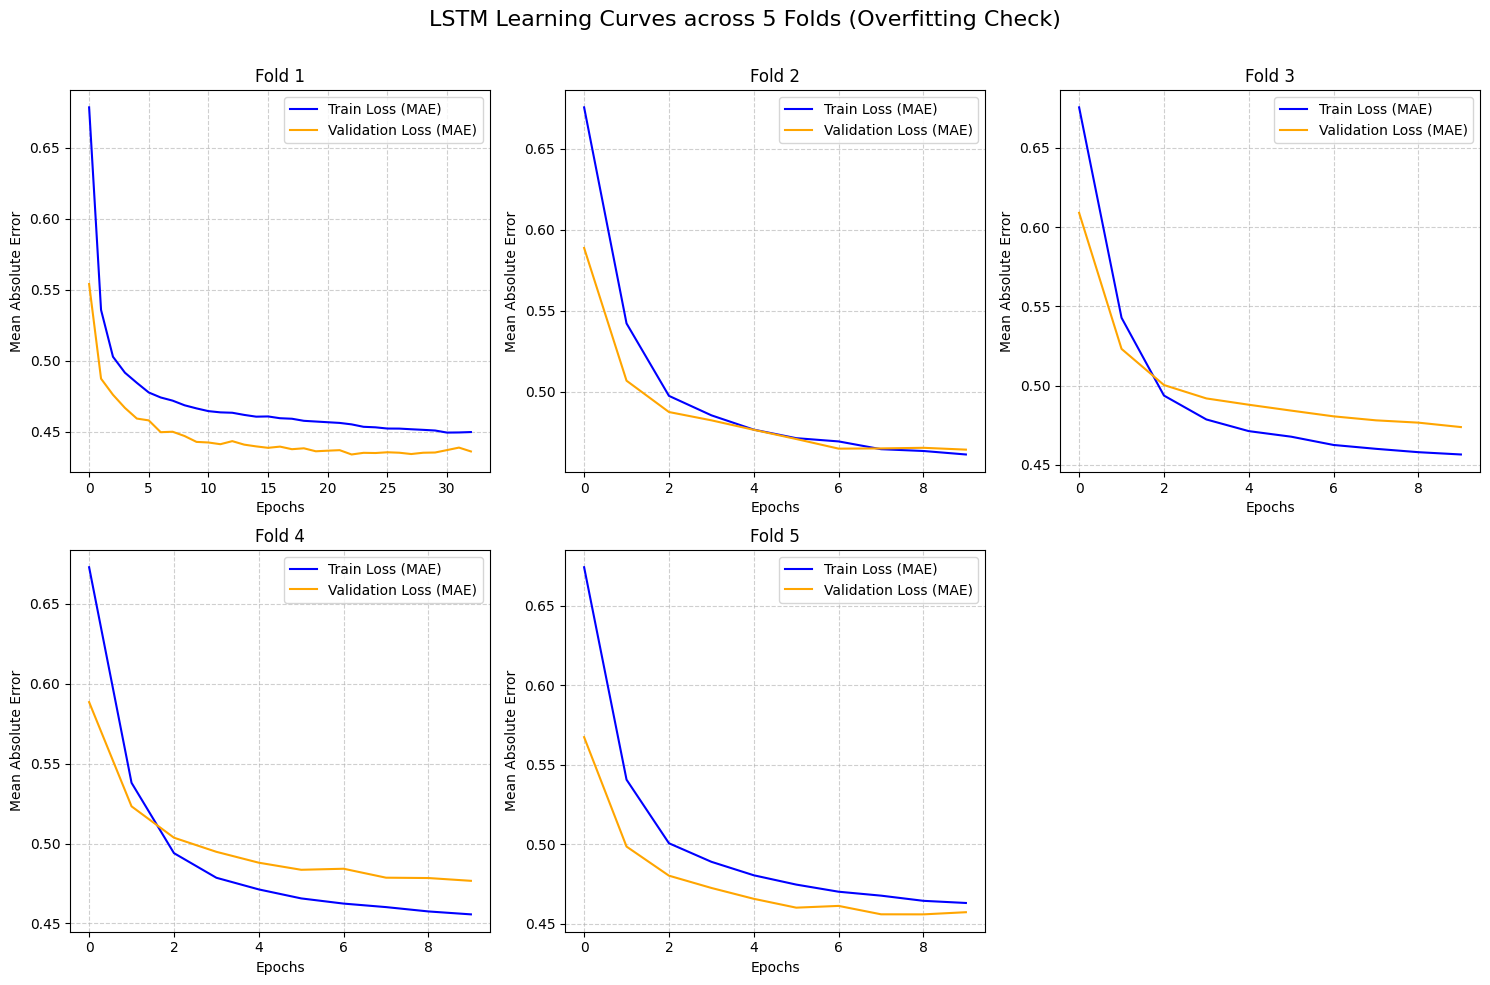


Training Final Master LSTM on FULL Training Set
Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.6659 - val_loss: 0.5393
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.5193 - val_loss: 0.4809
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4928 - val_loss: 0.4701
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.4848 - val_loss: 0.4669
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.4776 - val_loss: 0.4611
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4731 - val_loss: 0.4572
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4687 - val_loss: 0.4545
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4660 - val_loss: 0.4516
Epoch 9/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4637 - val_loss: 0.4505
Epoch 10/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4631 - val_loss: 0.4465
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

FINAL UNSEEN TEST RESULTS
Mas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold


# 1. DATA PREPARATION & SLICING
OBSERVED_DAYS = 9
PREDICT_DAYS = 21
num_features_in = X_padded.shape[2]

num_biomarker_features = len(final_biomarker_features)
biomarker_indices = [final_features_to_use.index(b) for b in final_biomarker_features]

valid_user_indices = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
Y_target_valid = Y_target[valid_user_indices]

X_input = X_valid[:, :OBSERVED_DAYS, :]
Y_future = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :][:, :, biomarker_indices]


X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_input, Y_future, Y_target_valid, test_size=0.2, random_state=42
)


# 2. DEFINING THE MODEL ARCHITECTURE
# We wrap the model in a function so we can generate a fresh model for every fold
def build_lstm_model():
    model = Sequential([
        Input(shape=(OBSERVED_DAYS, num_features_in)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PREDICT_DAYS * num_biomarker_features),
        Reshape((PREDICT_DAYS, num_biomarker_features))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model


# 3. K-FOLD CROSS VALIDATION (5 Folds)
print(f"\nStarting 5-Fold Cross Validation on Training Data")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
cv_mae_scores = []
all_histories = [] # To store data for our plots

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for train_idx, val_idx in kf.split(X_train):
    print(f"Training Fold {fold_no} / 5")

    # Slice the data for this specific fold
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    # Build a fresh model
    model_cv = build_lstm_model()

    # Train the model
    history = model_cv.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=100,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate the best weights on the fold's validation set
    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores.append(fold_loss)
    all_histories.append(history.history)

    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")
    fold_no += 1

print(f"\n[K-FOLD RESULTS] Average Validation MAE: {np.mean(cv_mae_scores):.4f} (+/- {np.std(cv_mae_scores):.4f})")


# 4. PLOTTING THE LEARNING CURVES (Overfitting Check)
plt.figure(figsize=(15, 10))
plt.suptitle('LSTM Learning Curves across 5 Folds (Overfitting Check)', fontsize=16)

for i, hist in enumerate(all_histories):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss (MAE)', color='blue')
    plt.plot(hist['val_loss'], label='Validation Loss (MAE)', color='orange')
    plt.title(f'Fold {i+1}')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


# 5. FINAL MASTER MODEL (For Classification)
print(f"\nTraining Final Master LSTM on FULL Training Set")
master_model = build_lstm_model()

master_history = master_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Final evaluation on the completely unseen X_test
y_pred_std = master_model.predict(X_test)
y_test_flat = y_test.reshape(y_test.shape[0], -1)
y_pred_std_flat = y_pred_std.reshape(y_pred_std.shape[0], -1)

mae_std = mean_absolute_error(y_test_flat, y_pred_std_flat)
r2_std = r2_score(y_test_flat, y_pred_std_flat)

print(f"\nFINAL UNSEEN TEST RESULTS")
print(f"Master LSTM MAE: {mae_std:.4f}")
print(f"Master LSTM R²:  {r2_std:.4f}")

2. Bidirectional LSTM


Starting 5-Fold Cross Validation on BiLSTM
Training BiLSTM Fold 1 / 5
Fold 1 MAE: 0.4370
Training BiLSTM Fold 2 / 5
Fold 2 MAE: 0.5661
Training BiLSTM Fold 3 / 5
Fold 3 MAE: 0.5902
Training BiLSTM Fold 4 / 5
Fold 4 MAE: 0.5750
Training BiLSTM Fold 5 / 5
Fold 5 MAE: 0.5667

[BiLSTM K-FOLD RESULTS] Average Validation MAE: 0.5470 (+/- 0.0557)


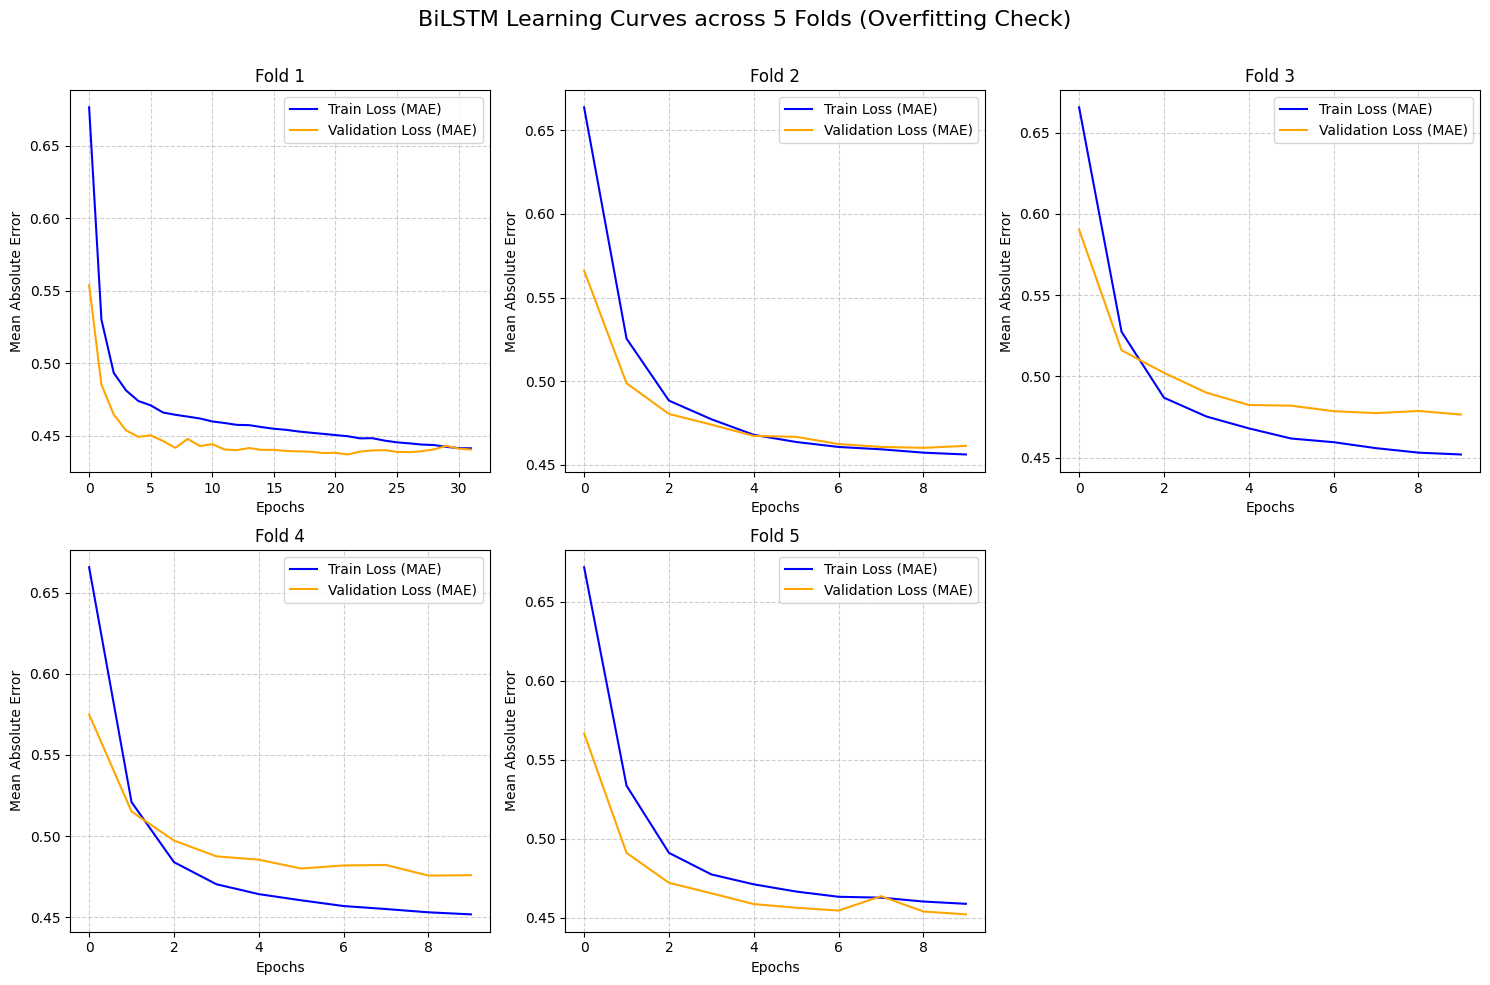


Training Final Master BiLSTM on FULL Training Set
Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.6568 - val_loss: 0.5423
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.5133 - val_loss: 0.4754
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.4833 - val_loss: 0.4655
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.4724 - val_loss: 0.4578
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4675 - val_loss: 0.4517
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.4648 - val_loss: 0.4489
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.4616 - val_loss: 0.4510
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.4598 - val_loss: 0.4474
Epoch 9/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.4584 - val_loss: 0.4451
Epoch 10/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.4573 - val_loss: 0.4467
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
MODEL COMPARISON: Standard v

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold


# 1. DEFINING THE BiLSTM ARCHITECTURE
# wrapping the BiLSTM in a function so we can generate a fresh model for every fold
def build_bilstm_model():
    model = Sequential([
        Input(shape=(OBSERVED_DAYS, num_features_in)),
        # BIDIRECTIONAL LSTM
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=False),

        Dense(64, activation='relu'),
        Dense(PREDICT_DAYS * num_biomarker_features),
        Reshape((PREDICT_DAYS, num_biomarker_features))
    ])

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# 2. K-FOLD CROSS VALIDATION (5 Folds)
print(f"\nStarting 5-Fold Cross Validation on BiLSTM")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
cv_mae_scores_bi = []
all_histories_bi = []

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for train_idx, val_idx in kf.split(X_train):
    print(f"Training BiLSTM Fold {fold_no} / 5")

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    model_cv_bi = build_bilstm_model()

    history_bi = model_cv_bi.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=100,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    fold_loss_bi = model_cv_bi.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_bi.append(fold_loss_bi)
    all_histories_bi.append(history_bi.history)

    print(f"Fold {fold_no} MAE: {fold_loss_bi:.4f}")
    fold_no += 1

print(f"\n[BiLSTM K-FOLD RESULTS] Average Validation MAE: {np.mean(cv_mae_scores_bi):.4f} (+/- {np.std(cv_mae_scores_bi):.4f})")

# 3. PLOTTING THE LEARNING CURVES
plt.figure(figsize=(15, 10))
plt.suptitle('BiLSTM Learning Curves across 5 Folds (Overfitting Check)', fontsize=16)

for i, hist in enumerate(all_histories_bi):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss (MAE)', color='blue')
    plt.plot(hist['val_loss'], label='Validation Loss (MAE)', color='orange')
    plt.title(f'Fold {i+1}')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# 4. FINAL MASTER BiLSTM & COMPARISON
print(f"\nTraining Final Master BiLSTM on FULL Training Set")
master_bilstm = build_bilstm_model()

master_bilstm_history = master_bilstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predict on completely unseen test data
y_pred_bi = master_bilstm.predict(X_test)
y_pred_bi_flat = y_pred_bi.reshape(y_pred_bi.shape[0], -1)

# Using y_test_flat from the Standard LSTM run
mae_bi = mean_absolute_error(y_test_flat, y_pred_bi_flat)
r2_bi = r2_score(y_test_flat, y_pred_bi_flat)


print(f"MODEL COMPARISON: Standard vs BiLSTM")
print(f"Standard LSTM MAE: {mae_std:.4f}")
print(f"BiLSTM MAE:        {mae_bi:.4f}  <-- (Lower is better)")
print(f"------------------------------------------")
print(f"Standard LSTM R²:  {r2_std:.4f}")
print(f"BiLSTM R²:         {r2_bi:.4f}  <-- (Higher is better)")

if mae_bi < mae_std:
    print("\nSUCCESS: Bidirectional architecture successfully captured deeper temporal context and improved accuracy")
else:
    print("\nThe Standard LSTM held its ground. The temporal patterns might be simple enough that reading backwards didn't add extra value.")

Comparing the resuls with the Naive Baseline model (LOCF)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("\nNAIVE BASELINE (Last Observation Carried Forward)")

# 1. extracting the exact biomarker values from the last observed day (Day 9)
# X_test shape is [Samples, OBSERVED_DAYS, Total_Features]
# We use our 'biomarker_indices' to safely take the surviving biomarkers
last_observed_day = X_test[:, -1, biomarker_indices]

# 2. Repeat that single day's values across all future 21 days
# np.repeat copies the Day 9 array across the time axis
naive_y_pred = np.repeat(last_observed_day[:, np.newaxis, :], PREDICT_DAYS, axis=1)

# 3. Flatten both arrays to calculate overall metrics
naive_y_test_flat = y_test.reshape(y_test.shape[0], -1)
naive_y_pred_flat = naive_y_pred.reshape(naive_y_pred.shape[0], -1)

# 4. Calculate Metrics
naive_mse = mean_squared_error(naive_y_test_flat, naive_y_pred_flat)
naive_rmse = np.sqrt(naive_mse)
naive_mae = mean_absolute_error(naive_y_test_flat, naive_y_pred_flat)
naive_r2 = r2_score(naive_y_test_flat, naive_y_pred_flat)

naive_sigma_y = np.std(naive_y_test_flat)
naive_nrmse = naive_rmse / naive_sigma_y if naive_sigma_y != 0 else 0

print(f"Naive LOCF Metrics:")
print(f"MSE:   {naive_mse:.4f}")
print(f"RMSE:  {naive_rmse:.4f}")
print(f"MAE:   {naive_mae:.4f}")
print(f"NRMSE: {naive_nrmse:.4f}")
print(f"R²:    {naive_r2:.4f}")

# 5. Direct Comparison with BiLSTM
print("MODEL COMPARISON: BiLSTM vs Naive Baseline")
print(f"BiLSTM MAE: {mae_bi:.4f}  |  Naive MAE: {naive_mae:.4f}")
print(f"BiLSTM R²:  {r2_bi:.4f}  |  Naive R²:  {naive_r2:.4f}")

if mae_bi < naive_mae:
    print("\nSUCCESS: Our BiLSTM is outperforming the Naive Baseline.")
else:
    print("\nWARNING: Our BiLSTM is performing worse than the Baseline.")


NAIVE BASELINE (Last Observation Carried Forward)
Naive LOCF Metrics:
MSE:   0.8906
RMSE:  0.9437
MAE:   0.5687
NRMSE: 0.9387
R²:    0.1047
MODEL COMPARISON: BiLSTM vs Naive Baseline
BiLSTM MAE: 0.5360  |  Naive MAE: 0.5687
BiLSTM R²:  0.3631  |  Naive R²:  0.1047

SUCCESS: Our BiLSTM is outperforming the Naive Baseline.


<h1>Classification (1D-CNN)</h1>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

print("        CLASSIFICATION             ")

# Defining Common Variables for the updated 30-Day Timeline
total_days = OBSERVED_DAYS + PREDICT_DAYS  # 9 + 21 = 30 days
total_features = len(final_features_to_use) # 15 optimized features


# SCENARIO 1: GROUND TRUTH
print("\nSCENARIO 1: GROUND TRUTH")

# Extract true 30-day sequences for the exact same test patients
X_full_30_days = X_valid[:, :total_days, :]

# Split identically to ensure y_test_labels lines up perfectly
_, X_test_ground_truth, _, _ = train_test_split(
    X_full_30_days, Y_target_valid, test_size=0.2, random_state=42
)

# Building Ground Truth CNN
model_cnn_gt = Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax') # 5 risk classifications
])

model_cnn_gt.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training CNN on Pure Ground Truth Data
model_cnn_gt.fit(X_test_ground_truth, y_test_labels, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

y_pred_probs_gt = model_cnn_gt.predict(X_test_ground_truth)
y_pred_classes_gt = np.argmax(y_pred_probs_gt, axis=1)
gt_acc = accuracy_score(y_test_labels, y_pred_classes_gt)


# SCENARIO 2: HYBRID (Real + Forecasted Data)
print("\nSCENARIO 2: HYBRID (9 Real + 21 Forecasted Days)")

# THE OVERWRITE STITCHING METHOD
# CNN requires 15 features to run. But earlier, we only told the BiLSTM to forecast the biomarkers. We have no future data for the lifestyle features
# 1. Average ALL 15 features over the first 9 days (the patient's baseline)
X_test_means = X_test.mean(axis=1, keepdims=True)

# 2. Stretch those averages across the next 21 days to create a baseline canvas
forecasted_sequence = np.repeat(X_test_means, PREDICT_DAYS, axis=1)

# 3. Overwrite ONLY the biomarker columns with the winning BiLSTM predictions
# (biomarker_indices is already mapped from the previous cells)
forecasted_sequence[:, :, biomarker_indices] = y_pred_bi

# 4. Stitch the 9 real days and the 21 forecasted days together on the time axis
full_stitched_sequence = np.concatenate([X_test, forecasted_sequence], axis=1)

# Building Hybrid CNN
model_cnn_hybrid = Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_cnn_hybrid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training CNN on Stitched Hybrid Data
model_cnn_hybrid.fit(full_stitched_sequence, y_test_labels, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

y_pred_probs_hybrid = model_cnn_hybrid.predict(full_stitched_sequence)
y_pred_classes_hybrid = np.argmax(y_pred_probs_hybrid, axis=1)
hybrid_acc = accuracy_score(y_test_labels, y_pred_classes_hybrid)


# FINAL COMPARISON
print("\n")
print("          FINAL CLASSIFICATION RESULTS       ")
print(f"Ground Truth Scenario Accuracy (Gold Standard): {gt_acc:.4f}")
print(f"Hybrid Scenario Accuracy (BiLSTM Forecasted):     {hybrid_acc:.4f}")

if hybrid_acc >= gt_acc * 0.90:
    print("\nSUCCESS: Our forecasting model is highly reliable! The Hybrid pipeline retains over 90% of the Ground Truth accuracy.")
else:
    print("\nNOTE: The Hybrid model is losing some accuracy compared to Ground Truth. Predicting 21 days out is noisy, causing the CNN to struggle slightly.")

        CLASSIFICATION             

SCENARIO 1: GROUND TRUTH
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

SCENARIO 2: HYBRID (9 Real + 21 Forecasted Days)
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


          FINAL CLASSIFICATION RESULTS       
Ground Truth Scenario Accuracy (Gold Standard): 0.8617
Hybrid Scenario Accuracy (BiLSTM Forecasted):     0.9383

SUCCESS: Our forecasting model is highly reliable! The Hybrid pipeline retains over 90% of the Ground Truth accuracy.


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report


# METRICS TABLE (Precision, Recall, F1)
print("\nDetailed Classification Metrics (Hybrid Model)")

# 1. Get the metrics as a structured dictionary
report_dict = classification_report(y_test_labels, y_pred_classes_hybrid, output_dict=True, zero_division=0)

# 2. Convert the dictionary into a Pandas DataFrame and transpose it
report_df = pd.DataFrame(report_dict).transpose()

# 3. Drop the summary rows so we only see the actual classes
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# 4. Select only the columns we care about and round them to 4 decimal places
metrics_df = report_df[['precision', 'recall', 'f1-score']].round(4)

# 5. Clean up the row names
metrics_df.index.name = 'Risk State'
metrics_df.reset_index(inplace=True)


risk_mapping = {
    '0': '0: Normal / Healthy',
    '1': '1: Mildly Elevated',
    '2': '2: Moderate Risk',
    '3': '3: High Risk',
    '4': '4: Critical Risk'
}

# Apply the mapping to the 'Risk State' column
metrics_df['Risk State'] = metrics_df['Risk State'].replace(risk_mapping)

# 6. Print the table
print(metrics_df.to_string(index=False))


Detailed Classification Metrics (Hybrid Model)
Risk State  precision  recall  f1-score
       1.0     0.9407  0.8284    0.8810
       2.0     0.9385  0.9763    0.9570
       3.0     0.9310  0.9000    0.9153
       4.0     0.9286  0.9286    0.9286
